# Model 1 — MLP Baseline

**Efficiency strategy:** Features are deterministic → precompute all 450K×20 features once on GPU before training. DataLoader then serves `(batch, 20)` tensors with zero HDF5 reads per epoch. Batch size raised to 4096 (was 256) since each sample is only 20 floats.

**Architecture:** Input(20) → Linear(128) → BN → ReLU → Dropout(0.2) → Linear(64) → BN → ReLU → Dropout(0.2) → Linear(1)

In [10]:
import h5py
import json
import math
import os
import sys
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm, trange

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.dataset import BatterySOHDataset, DEFAULT_TEST_BATTERIES
from src.models.mlp import SOHMLP, extract_features

print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch 2.7.1+cu118
CUDA available: True


In [11]:
H5_PATH      = '../data/processed/sequences.h5'
STATS_PATH   = '../data/processed/norm_stats.json'
CKPT_PATH    = '../results/checkpoints/mlp_best.pt'
METRICS_PATH = '../results/metrics/mlp_history.json'
FIG_DIR      = '../results/figures'

EPOCHS       = 100
BATCH_SIZE   = 65536  # GPU-resident tensors — no PCIe cost; ~6 batches/epoch, ~433 MB VRAM
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
RANDOM_SEED  = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
os.makedirs(os.path.dirname(METRICS_PATH), exist_ok=True)

def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()

Device: cuda


## Section 1 — Data Loading + Feature Precomputation

`extract_features()` is deterministic — same 20 stats for the same sample every epoch. Loading once and caching eliminates 1,438 HDF5 reads + 450K feature computations per epoch.

In [12]:
# Step 1: battery-level split
train_idx, test_idx = BatterySOHDataset.create_splits(H5_PATH)

if not os.path.exists(STATS_PATH):
    tmp = BatterySOHDataset(H5_PATH, indices=train_idx, normalize=False)
    tmp.compute_normalization_stats(STATS_PATH)

with open(STATS_PATH) as f:
    stats = json.load(f)
mean = np.array(stats['mean'], dtype=np.float32)
std  = np.array(stats['std'],  dtype=np.float32)

# Step 2: load full dataset into RAM and precompute features
print('Loading dataset into RAM...', flush=True)
with h5py.File(H5_PATH, 'r') as f:
    X_all = f['X'][:]           # (N, 301, 3) float32
    y_all = f['y'][:] / 100.0   # scale to [0, 1]
print(f'  X: {X_all.shape}  ({X_all.nbytes / 1024**3:.2f} GB)')

X_all = (X_all - mean) / (std + 1e-8)   # normalize

X_tensor = torch.from_numpy(X_all).to(DEVICE)
y_tensor = torch.from_numpy(y_all).to(DEVICE)
del X_all

print('Extracting features on GPU...', end=' ', flush=True)
with torch.no_grad():
    chunk = 65536
    feats_all = torch.cat(
        [extract_features(X_tensor[i:i+chunk]) for i in range(0, len(X_tensor), chunk)]
    )   # (N, 20)
del X_tensor
torch.cuda.empty_cache()
print(f'done. Shape: {feats_all.shape}')

# Step 3: split — keep tensors on GPU (~36 MB total, trivial for 7.7 GB VRAM)
train_idx_t = torch.from_numpy(train_idx)
test_idx_t  = torch.from_numpy(test_idx)

X_train = feats_all[train_idx_t]   # stays on GPU
y_train = y_tensor[train_idx_t]    # stays on GPU
X_test  = feats_all[test_idx_t]    # stays on GPU
y_test  = y_tensor[test_idx_t]     # stays on GPU
del feats_all, y_tensor

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Test batteries: {DEFAULT_TEST_BATTERIES}')
print(f'VRAM after split: {torch.cuda.memory_allocated() / 1024**2:.1f} MiB')

# Step 4: TensorDataset loaders — data already on GPU, no pin_memory needed
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f'Train batches/epoch: {len(train_loader)}')
xb, yb = next(iter(train_loader))
print(f'Batch x: {xb.shape}  device: {xb.device}  y range: [{yb.min():.3f}, {yb.max():.3f}]')

Train: 367,879 steps from 22 batteries: ['RW1', 'RW10', 'RW11', 'RW12', 'RW15', 'RW16', 'RW17', 'RW18', 'RW19', 'RW2', 'RW20', 'RW21', 'RW22', 'RW23', 'RW24', 'RW3', 'RW4', 'RW5', 'RW6', 'RW7', 'RW8', 'RW9']
Test:  82,647 steps from 6 batteries: ['RW13', 'RW14', 'RW25', 'RW26', 'RW27', 'RW28']
Loading dataset into RAM...
  X: (450526, 301, 3)  (1.52 GB)
Extracting features on GPU... done. Shape: torch.Size([450526, 20])
Train: 367,879  |  Test: 82,647
Test batteries: ['RW25', 'RW26', 'RW27', 'RW28', 'RW13', 'RW14']
VRAM after split: 86.2 MiB
Train batches/epoch: 6
Batch x: torch.Size([65536, 20])  device: cuda:0  y range: [0.000, 0.989]


## Section 2 — Feature Preview

In [14]:
FEATURE_NAMES = [
    'v_mean','v_std','v_min','v_max',
    'c_mean','c_std','c_min','c_max',
    't_mean','t_std','t_min','t_max',
    'v_range','v_start','v_end','v_delta',
    'c_range','c_abs_mean','t_range','t_delta',
]
sample = X_train[:512]
print(f"{'Feature':<14} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 56)
for i, name in enumerate(FEATURE_NAMES):
    col = sample[:, i]
    print(f'{name:<14} {col.mean():>10.4f} {col.std():>10.4f} {col.min():>10.4f} {col.max():>10.4f}')

Feature              Mean        Std        Min        Max
--------------------------------------------------------
v_mean             0.4126     1.0833    -1.4796     1.9961
v_std              0.1256     0.0778     0.0071     0.3963
v_min              0.1181     1.0569    -1.5293     1.9711
v_max              0.6762     0.9984    -1.3914     2.0064
c_mean            -0.6639     1.3106    -2.7856     1.4289
c_std              0.0002     0.0000     0.0001     0.0004
c_min             -0.6650     1.3111    -2.7884     1.4285
c_max             -0.6628     1.3111    -2.7852     1.4336
t_mean             0.1717     0.0037     0.1621     0.1817
t_std              0.0007     0.0006     0.0000     0.0028
t_min              0.1706     0.0036     0.1616     0.1817
t_max              0.1728     0.0039     0.1624     0.1821
v_range            0.5581     0.3618     0.0318     1.7997
v_start            0.4047     0.8480    -1.3914     1.9711
v_end              0.3873     1.2523    -1.5293     2.0064

## Section 3 — Model Architecture

In [16]:
set_seeds()
# SOHMLP.net takes (batch, 20) directly — bypasses extract_features() since
# features are already precomputed.
model = SOHMLP().net.to(DEVICE)
# torch.compile() gives ~1.3x step speedup but adds ~15s one-time compilation.
# Worth it only for very long runs (>800 epochs). Uncomment to enable.
# model = torch.compile(model)
print(SOHMLP())
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
with torch.no_grad():
    out = model(torch.randn(4, 20).to(DEVICE))
print(f'Input: (4, 20)  Output: {tuple(out.shape)}')

SOHMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 11,393
Input: (4, 20)  Output: (4, 1)


## Section 4 — Training

In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    bar = tqdm(loader, desc='Training', leave=True, unit='batch')
    for x, y in bar:
        # x, y already on GPU — no .to(DEVICE) needed
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(x).squeeze(1), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
        bar.set_postfix(loss=f'{loss.item():.4f}')
    return total / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    bar = tqdm(loader, desc='Validating', leave=True, unit='batch')
    for x, y in bar:
        # x already on GPU; collect outputs as CPU for numpy
        preds.append(model(x).squeeze(1).cpu())
        targets.append(y.cpu())
    preds   = torch.cat(preds).numpy() * 100.0
    targets = torch.cat(targets).numpy() * 100.0
    mae  = float(np.abs(preds - targets).mean())
    rmse = float(math.sqrt(((preds - targets)**2).mean()))
    return mae, rmse, preds, targets

In [18]:
set_seeds()
model     = SOHMLP().net.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = nn.MSELoss()

history      = {'train_loss': [], 'val_mae': [], 'val_rmse': []}
best_val_mae = float('inf')
no_improve   = 0

print(f'Batch size: {BATCH_SIZE}  |  Train batches/epoch: {len(train_loader)}')
print(f'VRAM before training: {torch.cuda.memory_allocated() / 1024**2:.1f} MiB')

for epoch in range(1, EPOCHS + 1):
    print(f'\n{"="*60}')
    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'{"="*60}')

    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_mae, val_rmse, _, _ = evaluate(model, test_loader)
    scheduler.step(val_mae)

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)

    lr_now = optimizer.param_groups[0]['lr']
    vram   = torch.cuda.memory_allocated() / 1024**2

    print(f'\nTrain Loss: {train_loss:.4f}')
    print(f'Val MAE:    {val_mae:.4f}%')
    print(f'Val RMSE:   {val_rmse:.4f}%')
    print(f'LR:         {lr_now:.6f}')
    print(f'VRAM:       {vram:.0f} MiB')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        no_improve   = 0
        torch.save({'epoch': epoch, 'val_mae': val_mae,
                    'model_state_dict': model.state_dict()}, CKPT_PATH)
        print(f'Model saved to {CKPT_PATH}')
        print('✓ New best model saved!')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

with open(METRICS_PATH, 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nBest val MAE: {best_val_mae:.4f}%  |  Checkpoint: {CKPT_PATH}')

Batch size: 65536  |  Train batches/epoch: 6
VRAM before training: 80.1 MiB

Epoch 1/100


Training:   0%|          | 0/6 [00:00<?, ?batch/s]

Validating:   0%|          | 0/2 [00:00<?, ?batch/s]


Train Loss: 0.4128
Val MAE:    70.9703%
Val RMSE:   72.2074%
LR:         0.001000
VRAM:       88 MiB
Model saved to ../results/checkpoints/mlp_best.pt
✓ New best model saved!

Epoch 2/100


Training:   0%|          | 0/6 [00:00<?, ?batch/s]

...

Validating:   0%|          | 0/2 [00:00<?, ?batch/s]


Train Loss: 0.0333
Val MAE:    10.0654%
Val RMSE:   12.2227%
LR:         0.000500
VRAM:       88 MiB

Epoch 49/100


Training:   0%|          | 0/6 [00:00<?, ?batch/s]

Validating:   0%|          | 0/2 [00:00<?, ?batch/s]


Train Loss: 0.0333
Val MAE:    10.0311%
Val RMSE:   12.1904%
LR:         0.000500
VRAM:       88 MiB
Early stopping at epoch 49.

Best val MAE: 9.9436%  |  Checkpoint: ../results/checkpoints/mlp_best.pt


## Section 5 — Results

In [19]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val MAE {ckpt['val_mae']:.4f}%)")
test_mae, test_rmse, preds, targets = evaluate(model, test_loader)
print(f'Test MAE:  {test_mae:.4f} SOH%')
print(f'Test RMSE: {test_rmse:.4f} SOH%')

Loaded best checkpoint (epoch 39, val MAE 9.9436%)


Validating:   0%|          | 0/2 [00:00<?, ?batch/s]

Test MAE:  9.9436 SOH%
Test RMSE: 12.1620 SOH%


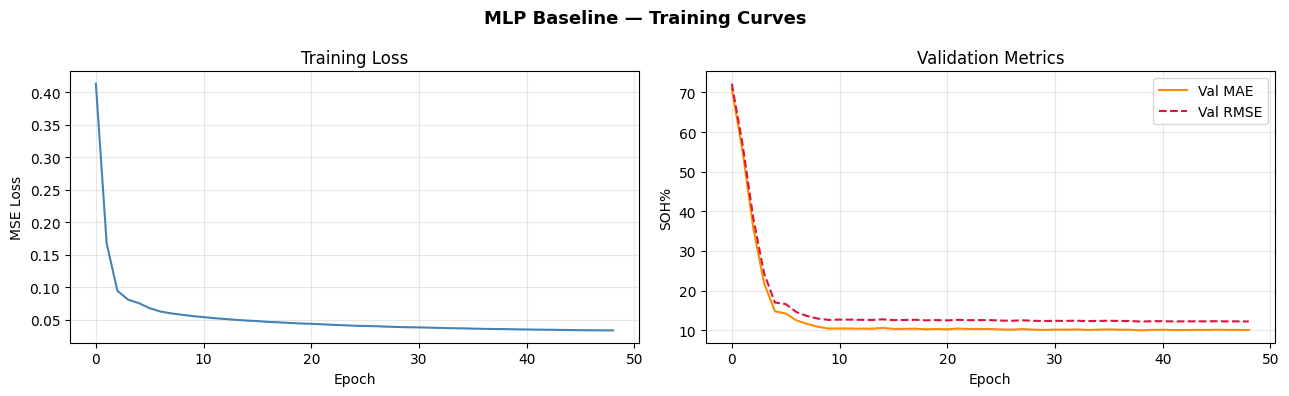

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], color='steelblue', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_mae'],  label='Val MAE',  color='darkorange', lw=1.5)
axes[1].plot(history['val_rmse'], label='Val RMSE', color='crimson', lw=1.5, ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('SOH%')
axes[1].set_title('Validation Metrics'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle('MLP Baseline — Training Curves', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mlp_training_curves.png'), dpi=150)
plt.show()

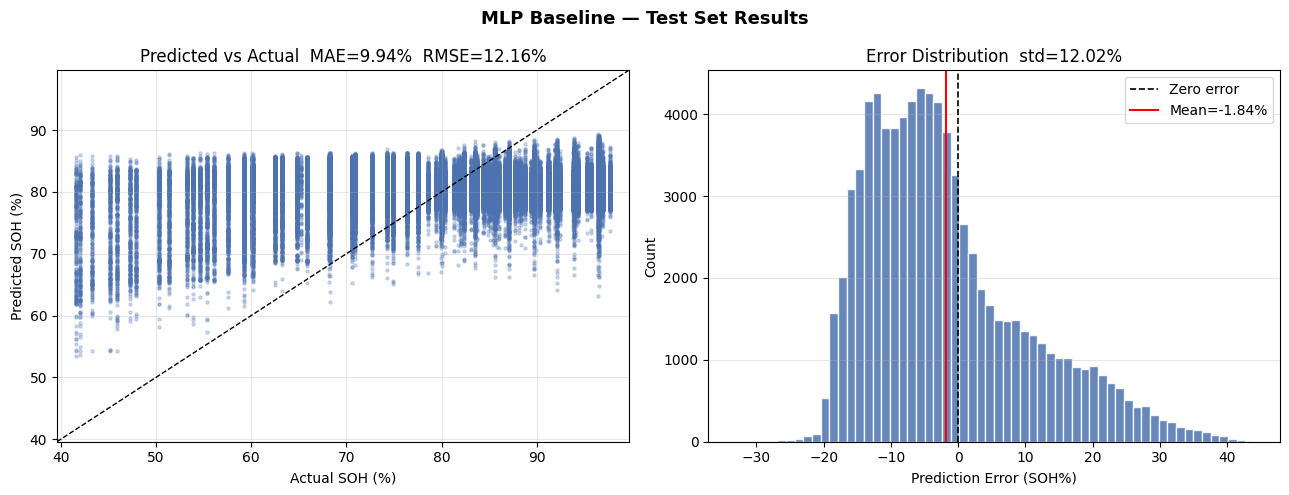

In [21]:
errors = preds - targets
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lims = [min(targets.min(), preds.min()) - 2, max(targets.max(), preds.max()) + 2]
axes[0].scatter(targets, preds, alpha=0.25, s=5, color='#4C72B0')
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual SOH (%)'); axes[0].set_ylabel('Predicted SOH (%)')
axes[0].set_title(f'Predicted vs Actual  MAE={test_mae:.2f}%  RMSE={test_rmse:.2f}%')
axes[0].grid(alpha=0.3)
axes[1].hist(errors, bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(0,             color='black', lw=1.2, ls='--', label='Zero error')
axes[1].axvline(errors.mean(), color='red',   lw=1.5, label=f'Mean={errors.mean():.2f}%')
axes[1].set_xlabel('Prediction Error (SOH%)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Error Distribution  std={errors.std():.2f}%')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
fig.suptitle('MLP Baseline — Test Set Results', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mlp_results.png'), dpi=150)
plt.show()

In [22]:
print('=' * 40)
print('MLP BASELINE — FINAL SUMMARY')
print('=' * 40)
print(f'Parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Batch size : {BATCH_SIZE}  (batches/epoch: {len(train_loader)})')
print(f'Test MAE   : {test_mae:.4f} SOH%')
print(f'Test RMSE  : {test_rmse:.4f} SOH%')
print(f'Error mean : {errors.mean():.4f} SOH%')
print(f'Error std  : {errors.std():.4f} SOH%')
print(f'Error p95  : {np.percentile(np.abs(errors), 95):.4f} SOH%')

MLP BASELINE — FINAL SUMMARY
Parameters : 11,393
Batch size : 65536  (batches/epoch: 6)
Test MAE   : 9.9436 SOH%
Test RMSE  : 12.1620 SOH%
Error mean : -1.8422 SOH%
Error std  : 12.0217 SOH%
Error p95  : 22.7366 SOH%
